### Le modele de GVAR 

In [70]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from dataclasses import dataclass

In [71]:
# ====== PARAMETRES DU MODELE ======
P = 0       # lags sur Z_i (domestique) : 1..P
P_star = 1  # lags sur Z_i* (étranger) : 0..P_star
L = 1       # lags sur X (macro) : 0..L

Z_FOLDER = "data/facteurs_systemiq/zt_am/zt_by_sector.csv"
MACRO_PATH = "data/macro_data/df_macro_stationary.csv"

OUTPUT_DIR = "data/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

W = "data/international_TES/W_USA.csv"


In [72]:
def load_Z_single_csv(path_csv: str) -> pd.DataFrame:
    """
    Charge un seul CSV contenant :
    sector, year_quarter, z_t
    et le transforme en matrice (date × secteur)
    """
    df = pd.read_csv(path_csv)

    df["year_quarter"] = pd.to_datetime(df["year_quarter"])

    # Pivot : lignes = date, colonnes = secteur
    Z = df.pivot(
        index="year_quarter",
        columns="sector",
        values="z_t"
    )

    Z = Z.sort_index()

    return Z


In [73]:
Z = load_Z_single_csv(Z_FOLDER)
Z.head(10)


sector,construction_immo,extraction_primaire,finance,industrie,info-com,public,services,services_pro
year_quarter,,,,,,,,
2010-07-01,-3.119644,2.534563,-0.787857,-0.014226,-3.292670,-1.474542,-2.020280,-2.270018
2010-10-01,-1.660812,0.635930,-1.219453,0.355094,-0.684983,-0.687493,-1.182131,-1.597358
2011-01-01,1.428445,0.751486,-2.079168,0.798452,-0.435846,-0.815319,-1.175695,-2.016439
2011-04-01,1.800480,1.284856,-1.264702,0.586932,-0.255213,0.220045,-1.503071,-2.016439
2011-07-01,1.929722,1.030703,-1.649227,-0.020633,-0.246125,0.218599,-0.750586,-2.016439
2011-10-01,-1.656445,0.949014,-1.228758,-0.130107,-0.198410,0.643175,-0.834454,-2.045196
2012-01-01,1.672773,0.778933,-0.611153,-0.170126,-0.358526,0.083938,-0.810922,-1.409588
2012-04-01,-1.552605,-0.154775,0.600996,-0.041919,0.890062,-0.131946,0.371942,-0.410847
2012-07-01,-1.456050,-0.166745,0.900720,-0.216857,-0.450470,1.693689,0.398834,-0.410847


In [74]:
W_PATH = "data/international_TES/W_USA.csv"

W = pd.read_csv(W_PATH, index_col=0)
print(W.shape)
print(W.index[:5])
print(W.columns[:5])


(8, 8)
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie'],
      dtype='str')
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie'],
      dtype='str')


In [75]:
W

,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro
Construction & immobilier,0.000000,0.091805,0.044308,0.042323,0.031832,0.351652,0.319931,0.118149
Finance,0.254573,0.000000,0.063530,0.029925,0.051587,0.268942,0.186638,0.144805
Industrie,0.228690,0.016663,0.000000,0.046987,0.111211,0.295704,0.225524,0.075221
Info-com,0.058195,0.099581,0.063383,0.000000,0.023975,0.297410,0.231898,0.225556
Primaires & énergie,0.124617,0.008341,0.605653,0.008270,0.000000,0.111432,0.114349,0.027337
Public & services non-marchands,0.143104,0.108869,0.115981,0.121381,0.104516,0.000000,0.262596,0.143553
Services,0.120531,0.034140,0.404891,0.051234,0.073470,0.217926,0.000000,0.097808
Services pro,0.123352,0.096037,0.132900,0.113900,0.047629,0.213727,0.272455,0.000000


In [76]:
print(Z.columns)
print(W.index)

Index(['construction_immo', 'extraction_primaire', 'finance', 'industrie',
       'info-com', 'public', 'services', 'services_pro'],
      dtype='str', name='sector')
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='str')


In [77]:
W.iloc[:8, :8]

,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro
Construction & immobilier,0.000000,0.091805,0.044308,0.042323,0.031832,0.351652,0.319931,0.118149
Finance,0.254573,0.000000,0.063530,0.029925,0.051587,0.268942,0.186638,0.144805
Industrie,0.228690,0.016663,0.000000,0.046987,0.111211,0.295704,0.225524,0.075221
Info-com,0.058195,0.099581,0.063383,0.000000,0.023975,0.297410,0.231898,0.225556
Primaires & énergie,0.124617,0.008341,0.605653,0.008270,0.000000,0.111432,0.114349,0.027337
Public & services non-marchands,0.143104,0.108869,0.115981,0.121381,0.104516,0.000000,0.262596,0.143553
Services,0.120531,0.034140,0.404891,0.051234,0.073470,0.217926,0.000000,0.097808
Services pro,0.123352,0.096037,0.132900,0.113900,0.047629,0.213727,0.272455,0.000000


In [78]:
df_macro_stas = pd.read_csv("data\macro_data\df_macro_stationary.csv")
df_macro_stas.head()

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_16180\2834272364.py:1: SyntaxWarning: invalid escape sequence '\m'
  df_macro_stas = pd.read_csv("data\macro_data\df_macro_stationary.csv")


,date,EU_Central_bank_Intervention_rate_policy_interest_rate,EU_GDP_Growth_Rate,JP_GDP_Growth_Rate,JP_Inflation_rate,JP_Oil_price,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,EU_Central_bank_Intervention_rate_policy_interest_rate_diff,...,US_GDP_log_hp_gap,US_GDP_log_hp_gap_diff,US_House_prices_residential_hp_gap,US_House_prices_residential_hp_gap_diff,US_Long_term_interest_rate_hp_gap,US_Long_term_interest_rate_hp_gap_diff,US_Oil_price_log,US_Oil_price_log_hp_gap,US_Unemployment_rate_hp_gap,US_Unemployment_rate_hp_gap_diff
0,2010-01-01,1.0,0.357380,1.242027,-1.166667,77.81,0.484501,3.716667,76.674837,NaN,...,-0.240971,NaN,6.075059,NaN,0.604782,NaN,4.339574,-0.262272,-0.143961,NaN
1,2010-04-01,1.0,0.999191,1.377096,-0.933333,80.94,0.967586,3.490000,78.845036,0.0,...,0.465834,0.706805,5.401879,-0.673180,0.457614,-0.147168,4.367484,-0.237845,-0.129613,0.014349
2,2010-07-01,1.0,0.478303,1.723737,-0.800000,75.44,0.771085,2.786667,76.675000,0.0,...,0.254099,-0.211735,3.589721,-1.812158,-0.166599,-0.624213,4.339576,-0.269074,-0.081841,0.047772
3,2010-10-01,1.0,0.612048,-0.858797,0.100000,83.37,0.525110,2.863333,87.033160,0.0,...,-0.114811,-0.368909,2.009748,-1.579973,-0.011853,0.154746,4.466289,-0.145205,0.166192,0.248033
4,2011-01-01,1.0,0.961402,-1.433205,-0.533333,98.52,-0.237205,3.460000,105.369424,0.0,...,NaN,NaN,-0.827594,-2.837341,0.661290,0.673144,4.657472,0.044092,-0.085291,-0.251483


In [79]:
# Convertir la date en datetime
df_macro_stas["date"] = pd.to_datetime(df_macro_stas["date"])

# Mettre date en index
df_macro_stas = df_macro_stas.set_index("date")

df_macro_stas.head()

,EU_Central_bank_Intervention_rate_policy_interest_rate,EU_GDP_Growth_Rate,JP_GDP_Growth_Rate,JP_Inflation_rate,JP_Oil_price,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,EU_Central_bank_Intervention_rate_policy_interest_rate_diff,EU_Effective_exchange_rate_hp_gap,...,US_GDP_log_hp_gap,US_GDP_log_hp_gap_diff,US_House_prices_residential_hp_gap,US_House_prices_residential_hp_gap_diff,US_Long_term_interest_rate_hp_gap,US_Long_term_interest_rate_hp_gap_diff,US_Oil_price_log,US_Oil_price_log_hp_gap,US_Unemployment_rate_hp_gap,US_Unemployment_rate_hp_gap_diff
date,,,,,,,,,,,,,,,,,,,,,
2010-01-01,1.0,0.357380,1.242027,-1.166667,77.81,0.484501,3.716667,76.674837,NaN,3.819471,...,-0.240971,NaN,6.075059,NaN,0.604782,NaN,4.339574,-0.262272,-0.143961,NaN
2010-04-01,1.0,0.999191,1.377096,-0.933333,80.94,0.967586,3.490000,78.845036,0.0,-1.544360,...,0.465834,0.706805,5.401879,-0.673180,0.457614,-0.147168,4.367484,-0.237845,-0.129613,0.014349
2010-07-01,1.0,0.478303,1.723737,-0.800000,75.44,0.771085,2.786667,76.675000,0.0,-1.790578,...,0.254099,-0.211735,3.589721,-1.812158,-0.166599,-0.624213,4.339576,-0.269074,-0.081841,0.047772
2010-10-01,1.0,0.612048,-0.858797,0.100000,83.37,0.525110,2.863333,87.033160,0.0,0.232728,...,-0.114811,-0.368909,2.009748,-1.579973,-0.011853,0.154746,4.466289,-0.145205,0.166192,0.248033
2011-01-01,1.0,0.961402,-1.433205,-0.533333,98.52,-0.237205,3.460000,105.369424,0.0,-0.114745,...,NaN,NaN,-0.827594,-2.837341,0.661290,0.673144,4.657472,0.044092,-0.085291,-0.251483


In [80]:
# Sélectionner colonnes contenant "US_"
us_cols = [col for col in df_macro_stas.columns if col.startswith("US_")]

df_macro_us = df_macro_stas[us_cols].copy()

df_macro_us.head()

,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Effective_exchange_rate_hp_gap,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_GDP_log,US_GDP_log_hp_gap,US_GDP_log_hp_gap_diff,US_House_prices_residential_hp_gap,US_House_prices_residential_hp_gap_diff,US_Long_term_interest_rate_hp_gap,US_Long_term_interest_rate_hp_gap_diff,US_Oil_price_log,US_Oil_price_log_hp_gap,US_Unemployment_rate_hp_gap,US_Unemployment_rate_hp_gap_diff
date,,,,,,,,,,,,,,,,,,
2010-01-01,0.484501,3.716667,76.674837,NaN,3.739092,NaN,0.066930,-0.724636,-0.240971,NaN,6.075059,NaN,0.604782,NaN,4.339574,-0.262272,-0.143961,NaN
2010-04-01,0.967586,3.490000,78.845036,0.0,4.981713,1.242621,-0.088895,-0.032951,0.465834,0.706805,5.401879,-0.673180,0.457614,-0.147168,4.367484,-0.237845,-0.129613,0.014349
2010-07-01,0.771085,2.786667,76.675000,0.0,3.671997,-1.309716,-0.016660,-0.259957,0.254099,-0.211735,3.589721,-1.812158,-0.166599,-0.624213,4.339576,-0.269074,-0.081841,0.047772
2010-10-01,0.525110,2.863333,87.033160,0.0,0.004494,-3.667503,0.050870,-0.644147,-0.114811,-0.368909,2.009748,-1.579973,-0.011853,0.154746,4.466289,-0.145205,0.166192,0.248033
2011-01-01,-0.237205,3.460000,105.369424,0.0,-1.191876,-1.196370,0.074041,NaN,NaN,NaN,-0.827594,-2.837341,0.661290,0.673144,4.657472,0.044092,-0.085291,-0.251483


In [81]:
macro_vars = [
    "US_GDP_Growth_Rate",
    "US_Central_bank_Intervention_rate_policy_interest_rate_diff",
    "US_Long_term_interest_rate_hp_gap_diff",
    "US_Unemployment_rate_hp_gap_diff",
    "US_House_prices_residential_hp_gap_diff",
    "US_Effective_exchange_rate_hp_gap_diff",
    "US_Equity_prices_log_hp_gap",
    "US_Oil_price_log_hp_gap"
]

In [82]:
X = df_macro_stas[macro_vars].copy()
X.head()

,US_GDP_Growth_Rate,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Long_term_interest_rate_hp_gap_diff,US_Unemployment_rate_hp_gap_diff,US_House_prices_residential_hp_gap_diff,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_Oil_price_log_hp_gap
date,,,,,,,,
2010-01-01,0.484501,NaN,NaN,NaN,NaN,NaN,0.066930,-0.262272
2010-04-01,0.967586,0.0,-0.147168,0.014349,-0.673180,1.242621,-0.088895,-0.237845
2010-07-01,0.771085,0.0,-0.624213,0.047772,-1.812158,-1.309716,-0.016660,-0.269074
2010-10-01,0.525110,0.0,0.154746,0.248033,-1.579973,-3.667503,0.050870,-0.145205
2011-01-01,-0.237205,0.0,0.673144,-0.251483,-2.837341,-1.196370,0.074041,0.044092


In [83]:
# Au lieu de chercher la colonne "date", on manipule directement l'index
X.index = pd.to_datetime(X.index)
X = X.sort_index()
X.head()

,US_GDP_Growth_Rate,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Long_term_interest_rate_hp_gap_diff,US_Unemployment_rate_hp_gap_diff,US_House_prices_residential_hp_gap_diff,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_Oil_price_log_hp_gap
date,,,,,,,,
2010-01-01,0.484501,NaN,NaN,NaN,NaN,NaN,0.066930,-0.262272
2010-04-01,0.967586,0.0,-0.147168,0.014349,-0.673180,1.242621,-0.088895,-0.237845
2010-07-01,0.771085,0.0,-0.624213,0.047772,-1.812158,-1.309716,-0.016660,-0.269074
2010-10-01,0.525110,0.0,0.154746,0.248033,-1.579973,-3.667503,0.050870,-0.145205
2011-01-01,-0.237205,0.0,0.673144,-0.251483,-2.837341,-1.196370,0.074041,0.044092


In [84]:
print("Colonnes Z :")
print(Z.columns)

print("\nIndex W :")
print(W.index)


Colonnes Z :
Index(['construction_immo', 'extraction_primaire', 'finance', 'industrie',
       'info-com', 'public', 'services', 'services_pro'],
      dtype='str', name='sector')

Index W :
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='str')


In [85]:
rename_dict = {
    "construction_immo": "Construction & immobilier",
    "extraction_primaire": "Primaires & énergie",
    "finance": "Finance",
    "industrie": "Industrie",
    "info-com": "Info-com",
    "public": "Public & services non-marchands",
    "services": "Services",
    "services_pro": "Services pro"
}

Z = Z.rename(columns=rename_dict)


In [86]:
print("Colonnes Z :")
print(Z.columns)

print("\nIndex W :")
print(W.index)


Colonnes Z :
Index(['Construction & immobilier', 'Primaires & énergie', 'Finance',
       'Industrie', 'Info-com', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='str', name='sector')

Index W :
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='str')


In [87]:
# Secteurs : Z doit contenir tous les secteurs de W
missing = sorted(set(W.index) - set(Z.columns))
if missing:
    raise ValueError(f"Z ne contient pas tous les secteurs de W : {missing}")

# Garder uniquement les secteurs de W, dans le même ordre
Z = Z[W.index].copy()

# Alignement sur dates communes (et dropna)
df_base = pd.concat([Z, X], axis=1).dropna()

print("Z:", Z.shape, "| X:", X.shape, "| Base alignée:", df_base.shape)

Z: (51, 8) | X: (56, 8) | Base alignée: (51, 16)


C:\Users\HP\AppData\Local\Temp\ipykernel_16180\2212304547.py:10: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_base = pd.concat([Z, X], axis=1).dropna()


In [88]:
X_scenario=pd.read_csv("data/ngfs_data/ngfs_us.csv")

In [89]:
df_base.head()

,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro,US_GDP_Growth_Rate,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Long_term_interest_rate_hp_gap_diff,US_Unemployment_rate_hp_gap_diff,US_House_prices_residential_hp_gap_diff,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_Oil_price_log_hp_gap
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018,0.771085,0.0,-0.624213,0.047772,-1.812158,-1.309716,-0.016660,-0.269074
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358,0.525110,0.0,0.154746,0.248033,-1.579973,-3.667503,0.050870,-0.145205
2011-01-01,1.428445,-2.079168,0.798452,-0.435846,0.751486,-0.815319,-1.175695,-2.016439,-0.237205,0.0,0.673144,-0.251483,-2.837341,-1.196370,0.074041,0.044092
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439,0.676582,0.0,-0.175677,0.249117,-1.732493,-1.589651,0.040477,0.153057
2011-07-01,1.929722,-1.649227,-0.020633,-0.246125,1.030703,0.218599,-0.750586,-2.016439,-0.022313,0.0,-0.712131,0.149890,-0.319915,0.296731,-0.143873,0.117724


In [90]:
def compute_Z_star(Z: pd.DataFrame, W: pd.DataFrame) -> pd.DataFrame:
    W2 = W.copy()
    Z_star = Z @ W2.T
    Z_star.columns = [f"{c}_star" for c in Z_star.columns]
    return Z_star

Z_star = compute_Z_star(Z, W)

# Dataset complet (Z, Z_star, X)
df_all = pd.concat([Z, Z_star, X], axis=1).dropna()
df_all.head()


C:\Users\HP\AppData\Local\Temp\ipykernel_16180\2245030967.py:10: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_all = pd.concat([Z, Z_star, X], axis=1).dropna()


,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro,Construction & immobilier_star,Finance_star,...,Services_star,Services pro_star,US_GDP_Growth_Rate,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Long_term_interest_rate_hp_gap_diff,US_Unemployment_rate_hp_gap_diff,US_House_prices_residential_hp_gap_diff,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_Oil_price_log_hp_gap
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018,-1.564711,-1.865200,...,-0.934521,-1.582271,0.771085,0.0,-0.624213,0.047772,-1.812158,-1.309716,-0.016660,-0.269074
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358,-0.913652,-1.024763,...,-0.392467,-0.791531,0.525110,0.0,0.154746,0.248033,-1.579973,-3.667503,0.050870,-0.145205
2011-01-01,1.428445,-2.079168,0.798452,-0.435846,0.751486,-0.815319,-1.175695,-2.016439,-1.051116,-0.290600,...,0.082451,-0.425792,-0.237205,0.0,0.673144,-0.251483,-2.837341,-1.196370,0.074041,0.044092
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439,-0.701743,0.040945,...,0.343530,-0.151725,0.676582,0.0,-0.175677,0.249117,-1.732493,-1.589651,0.040477,0.153057
2011-07-01,1.929722,-1.649227,-0.020633,-0.246125,1.030703,0.218599,-0.750586,-2.016439,-0.531434,0.162462,...,0.081461,-0.059817,-0.022313,0.0,-0.712131,0.149890,-0.319915,0.296731,-0.143873,0.117724


#################3 - stationnary + stepwise non par blocl ######

In [91]:
def build_full_design(df_all, sector, macro_cols, Pmax, Lmax):
    """
    Construit la matrice Xreg complète pour le secteur:
    const + Z*_lags (0..Pmax) + macros (k=1..K, l=0..Lmax)
    Retourne df_reg = [y | Xreg] dropna
    """
    y = df_all[sector].rename("y")
    parts = []

    # Z* lags
    zstar_col = f"{sector}_star"
    for p in range(Pmax + 1):
        parts.append(df_all[zstar_col].shift(p).rename(f"ZstarL{p}"))

    # Macros lags variable par variable
    for l in range(Lmax + 1):
        parts.append(df_all[macro_cols].shift(l).add_prefix(f"X_L{l}_"))

    Xreg = pd.concat(parts, axis=1)
    Xreg = sm.add_constant(Xreg, has_constant="add")

    df_reg = pd.concat([y, Xreg], axis=1).dropna()
    return df_reg

In [92]:
from sklearn.linear_model import Ridge
import numpy as np
import pandas as pd

def fit_bic(df_reg, kept_cols, alpha=10.0):
    """
    Estimation Ridge à la place de OLS.
    kept_cols doit inclure 'const'.
    Retourne params, pseudo-BIC
    """

    y = df_reg["y"].values
    X = df_reg[kept_cols].values

    model = Ridge(alpha=alpha, fit_intercept=False)
    model.fit(X, y)

    y_hat = model.predict(X)
    resid = y - y_hat

    n = len(y)
    k = X.shape[1]

    sigma2 = np.mean(resid**2)
    bic = n * np.log(sigma2) + k * np.log(n)

    params = pd.Series(model.coef_, index=kept_cols)

    return params, bic

In [93]:
def backward_stepwise_bic(df_reg, candidate_cols, always_keep=("const",), min_keep=3):
    """
    Backward elimination: on part avec tous les candidats,
    et on retire 1 variable à la fois si BIC diminue.
    """
    kept = list(dict.fromkeys(list(always_keep) + list(candidate_cols)))
    kept = [c for c in kept if c in df_reg.columns]

    res_full, best_bic = fit_bic(df_reg, kept)

    improved = True
    while improved:
        improved = False
        best_drop = None
        best_drop_bic = best_bic

        # candidats supprimables
        droppable = [c for c in kept if c not in always_keep]

        if len(droppable) <= min_keep:
            break

        for c in droppable:
            trial = [k for k in kept if k != c]
            try:
                _, bic = fit_bic(df_reg, trial)
            except Exception:
                continue

            if bic < best_drop_bic:
                best_drop_bic = bic
                best_drop = c

        if best_drop is not None:
            kept.remove(best_drop)
            best_bic = best_drop_bic
            improved = True

    final_res, final_bic = fit_bic(df_reg, kept)
    return kept, final_res, final_bic

In [94]:
def stepwise_macros_then_zstar(df_all, sector, macro_cols, Pmax=4, Lmax=4, iterate=False):
    df_reg = build_full_design(df_all, sector, macro_cols, Pmax=Pmax, Lmax=Lmax)

    # Colonnes Z* et macro dans le df_reg
    zstar_cols = [c for c in df_reg.columns if c.startswith("ZstarL")]
    macro_lag_cols = [c for c in df_reg.columns if c.startswith("X_L")]

    # --- Phase A : stepwise sur macros uniquement (Z* toujours gardé au départ)
    always_keep_A = ("const",) + tuple(zstar_cols)
    kept_A, res_A, bic_A = backward_stepwise_bic(
        df_reg=df_reg,
        candidate_cols=macro_lag_cols,
        always_keep=always_keep_A
    )

    # --- Phase B : stepwise sur Z* uniquement (macros sélectionnées fixées)
    selected_macro_cols = [c for c in kept_A if c.startswith("X_L")]
    always_keep_B = ("const",) + tuple(selected_macro_cols)
    kept_B, res_B, bic_B = backward_stepwise_bic(
        df_reg=df_reg,
        candidate_cols=zstar_cols,
        always_keep=always_keep_B
    )

    if not iterate:
        return kept_B, res_B, bic_B

    # Optionnel : itération A↔B (1 tour)
    # Re-phase A en gardant les Z* sélectionnés
    zstar_selected = [c for c in kept_B if c.startswith("ZstarL")]
    always_keep_A2 = ("const",) + tuple(zstar_selected)
    kept_A2, res_A2, bic_A2 = backward_stepwise_bic(
        df_reg=df_reg,
        candidate_cols=macro_lag_cols,
        always_keep=always_keep_A2
    )

    selected_macro_cols2 = [c for c in kept_A2 if c.startswith("X_L")]
    always_keep_B2 = ("const",) + tuple(selected_macro_cols2)
    kept_B2, res_B2, bic_B2 = backward_stepwise_bic(
        df_reg=df_reg,
        candidate_cols=zstar_cols,
        always_keep=always_keep_B2
    )

    return kept_B2, res_B2, bic_B2

In [95]:
sector = "Construction & immobilier"
macro_cols = list(X.columns)  # ou ta liste macro réduite

kept_cols, res, bic = stepwise_macros_then_zstar(
    df_all=df_all,
    sector=sector,
    macro_cols=macro_cols,
    Pmax=4,
    Lmax=4,      # retard max macro
    iterate=True # optionnel
)

print("BIC final:", bic)
print("Nb variables gardées:", len(kept_cols))
print("Variables gardées:", kept_cols)



BIC final: 12.45053917036703
Nb variables gardées: 7
Variables gardées: ['const', 'X_L0_US_House_prices_residential_hp_gap_diff', 'X_L1_US_House_prices_residential_hp_gap_diff', 'X_L4_US_House_prices_residential_hp_gap_diff', 'ZstarL0', 'ZstarL1', 'ZstarL4']


In [96]:
print(res.sort_values(key=abs, ascending=False))

X_L1_US_House_prices_residential_hp_gap_diff   -0.285159
X_L0_US_House_prices_residential_hp_gap_diff    0.221625
X_L4_US_House_prices_residential_hp_gap_diff    0.190870
ZstarL1                                         0.151890
ZstarL0                                        -0.099946
ZstarL4                                        -0.065212
const                                           0.037260
dtype: float64


In [97]:
def run_stepwise_all_sectors(df_all, sectors, macro_cols, Pmax=4, Lmax=4, iterate=False):
    # liste de colonnes possibles (max) pour construire un coef_df stable
    max_cols = ["const"] + [f"ZstarL{p}" for p in range(Pmax+1)]
    for l in range(Lmax+1):
        max_cols += [f"X_L{l}_{c}" for c in macro_cols]

    coef_df = pd.DataFrame(index=sectors, columns=max_cols, dtype=float)
    bic_series = pd.Series(index=sectors, dtype=float)

    kept_by_sector = {}

    for s in sectors:
        kept_cols, res, bic = stepwise_macros_then_zstar(
            df_all=df_all,
            sector=s,
            macro_cols=macro_cols,
            Pmax=Pmax,
            Lmax=Lmax,
            iterate=iterate
        )
        kept_by_sector[s] = kept_cols
        bic_series.loc[s] = bic

        # remplir coef_df (les non sélectionnés restent NaN)
        for name, val in res.params.items():
            if name in coef_df.columns:
                coef_df.loc[s, name] = val

    return coef_df, bic_series, kept_by_sector

In [98]:
def run_stepwise_all_sectors(df_all, sectors, macro_cols, Pmax=4, Lmax=4, iterate=False):

    max_cols = ["const"] + [f"ZstarL{p}" for p in range(Pmax+1)]
    for l in range(Lmax+1):
        max_cols += [f"X_L{l}_{c}" for c in macro_cols]

    coef_df = pd.DataFrame(index=sectors, columns=max_cols, dtype=float)
    bic_series = pd.Series(index=sectors, dtype=float)

    kept_by_sector = {}

    for s in sectors:

        kept_cols, params, bic = stepwise_macros_then_zstar(
            df_all=df_all,
            sector=s,
            macro_cols=macro_cols,
            Pmax=Pmax,
            Lmax=Lmax,
            iterate=iterate
        )

        kept_by_sector[s] = kept_cols
        bic_series.loc[s] = bic

        for name, val in params.items():
            if name in coef_df.columns:
                coef_df.loc[s, name] = val

    return coef_df, bic_series, kept_by_sector

In [99]:
sectors = list(Z.columns)
macro_cols = list(X.columns)

In [100]:
coef_df, bic_series, kept_by_sector = run_stepwise_all_sectors(
    df_all=df_all,
    sectors=sectors,
    macro_cols=macro_cols,
    Pmax=4,
    Lmax=4,
    iterate=False
)
print(kept_by_sector)

{'Construction & immobilier': ['const', 'X_L0_US_House_prices_residential_hp_gap_diff', 'X_L1_US_House_prices_residential_hp_gap_diff', 'X_L4_US_House_prices_residential_hp_gap_diff', 'ZstarL0', 'ZstarL1', 'ZstarL4'], 'Finance': ['const', 'X_L2_US_GDP_Growth_Rate', 'X_L2_US_Unemployment_rate_hp_gap_diff', 'X_L2_US_House_prices_residential_hp_gap_diff', 'ZstarL0', 'ZstarL1', 'ZstarL4'], 'Industrie': ['const', 'X_L0_US_Unemployment_rate_hp_gap_diff', 'X_L2_US_House_prices_residential_hp_gap_diff', 'X_L3_US_Oil_price_log_hp_gap', 'ZstarL0', 'ZstarL1', 'ZstarL4'], 'Info-com': ['const', 'X_L0_US_Unemployment_rate_hp_gap_diff', 'X_L0_US_House_prices_residential_hp_gap_diff', 'X_L1_US_GDP_Growth_Rate', 'X_L2_US_Unemployment_rate_hp_gap_diff', 'X_L3_US_Unemployment_rate_hp_gap_diff', 'X_L4_US_Unemployment_rate_hp_gap_diff', 'X_L4_US_House_prices_residential_hp_gap_diff', 'ZstarL0', 'ZstarL1', 'ZstarL3'], 'Primaires & énergie': ['const', 'X_L3_US_House_prices_residential_hp_gap_diff', 'X_L3_US_

In [101]:
coef_df

,const,ZstarL0,ZstarL1,ZstarL2,ZstarL3,ZstarL4,X_L0_US_GDP_Growth_Rate,X_L0_US_Central_bank_Intervention_rate_policy_interest_rate_diff,X_L0_US_Long_term_interest_rate_hp_gap_diff,X_L0_US_Unemployment_rate_hp_gap_diff,...,X_L3_US_Equity_prices_log_hp_gap,X_L3_US_Oil_price_log_hp_gap,X_L4_US_GDP_Growth_Rate,X_L4_US_Central_bank_Intervention_rate_policy_interest_rate_diff,X_L4_US_Long_term_interest_rate_hp_gap_diff,X_L4_US_Unemployment_rate_hp_gap_diff,X_L4_US_House_prices_residential_hp_gap_diff,X_L4_US_Effective_exchange_rate_hp_gap_diff,X_L4_US_Equity_prices_log_hp_gap,X_L4_US_Oil_price_log_hp_gap
Construction & immobilier,0.037260,-0.099946,0.151890,NaN,NaN,-0.065212,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.190870,NaN,NaN,NaN
Finance,-0.182085,0.501628,0.261252,NaN,NaN,-0.082606,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Industrie,0.006240,0.588063,0.377145,NaN,NaN,-0.204439,NaN,NaN,NaN,0.057067,...,NaN,-0.159759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Info-com,0.098358,0.275269,0.260817,NaN,0.17674,NaN,NaN,NaN,NaN,0.140576,...,NaN,NaN,NaN,NaN,NaN,0.107687,-0.146307,NaN,NaN,NaN
Primaires & énergie,0.010108,0.575424,NaN,0.205942,NaN,-0.180237,NaN,NaN,NaN,NaN,...,NaN,-0.350144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.433741
Public & services non-marchands,-0.095626,0.275435,0.206947,NaN,NaN,-0.142072,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.074543,NaN,NaN
Services,-0.070623,0.450427,0.244987,0.127090,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.179414,NaN,NaN,NaN,NaN,NaN
Services pro,-0.312263,0.597299,0.342469,NaN,NaN,-0.146267,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.096620,NaN,NaN


In [102]:
sectors = list(W.index)
macro_cols = list(X.columns)  # les macros que tu as retenues (K)

coef_df0 = coef_df.reindex(index=sectors).copy()
coef_df0 = coef_df0.fillna(0.0)  # <- règle : non retenu => 0

In [103]:
coef_df0

,const,ZstarL0,ZstarL1,ZstarL2,ZstarL3,ZstarL4,X_L0_US_GDP_Growth_Rate,X_L0_US_Central_bank_Intervention_rate_policy_interest_rate_diff,X_L0_US_Long_term_interest_rate_hp_gap_diff,X_L0_US_Unemployment_rate_hp_gap_diff,...,X_L3_US_Equity_prices_log_hp_gap,X_L3_US_Oil_price_log_hp_gap,X_L4_US_GDP_Growth_Rate,X_L4_US_Central_bank_Intervention_rate_policy_interest_rate_diff,X_L4_US_Long_term_interest_rate_hp_gap_diff,X_L4_US_Unemployment_rate_hp_gap_diff,X_L4_US_House_prices_residential_hp_gap_diff,X_L4_US_Effective_exchange_rate_hp_gap_diff,X_L4_US_Equity_prices_log_hp_gap,X_L4_US_Oil_price_log_hp_gap
Construction & immobilier,0.037260,-0.099946,0.151890,0.000000,0.00000,-0.065212,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.190870,0.000000,0.0,0.000000
Finance,-0.182085,0.501628,0.261252,0.000000,0.00000,-0.082606,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
Industrie,0.006240,0.588063,0.377145,0.000000,0.00000,-0.204439,0.0,0.0,0.0,0.057067,...,0.0,-0.159759,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
Info-com,0.098358,0.275269,0.260817,0.000000,0.17674,0.000000,0.0,0.0,0.0,0.140576,...,0.0,0.000000,0.0,0.0,0.000000,0.107687,-0.146307,0.000000,0.0,0.000000
Primaires & énergie,0.010108,0.575424,0.000000,0.205942,0.00000,-0.180237,0.0,0.0,0.0,0.000000,...,0.0,-0.350144,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,-0.433741
Public & services non-marchands,-0.095626,0.275435,0.206947,0.000000,0.00000,-0.142072,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.074543,0.0,0.000000
Services,-0.070623,0.450427,0.244987,0.127090,0.00000,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,-0.179414,0.000000,0.000000,0.000000,0.0,0.000000
Services pro,-0.312263,0.597299,0.342469,0.000000,0.00000,-0.146267,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,-0.096620,0.0,0.000000


In [104]:
def build_B_matrices_from_coef(W: pd.DataFrame, coef_df0: pd.DataFrame, P_star: int) -> dict:
    N = W.shape[0]
    sectors = list(W.index)

    W2 = W.copy()

    B = {}
    for p in range(0, P_star + 1):
        col = f"ZstarL{p}"
        beta = coef_df0[col].reindex(sectors).values.reshape(N, 1) if col in coef_df0.columns else np.zeros((N,1))
        Bp = beta * W2.values  # diag(beta) @ W  (broadcasting)
        B[p] = pd.DataFrame(Bp, index=sectors, columns=sectors)

    return B

B = build_B_matrices_from_coef(W, coef_df0, P_star=4)
print("B0 shape:", B[0].shape)

B0 shape: (8, 8)


In [105]:
def build_Gamma_matrices_from_coef(coef_df0: pd.DataFrame, sectors: list, macro_cols: list, L: int) -> dict:
    Gamma = {}
    for l in range(0, L + 1):
        cols_l = [f"X_L{l}_{m}" for m in macro_cols]
        # si une colonne manque (par ex. jamais créée), on la crée à 0
        for c in cols_l:
            if c not in coef_df0.columns:
                coef_df0[c] = 0.0

        Gammal = coef_df0.loc[sectors, cols_l].values  # (N×K)
        Gamma[l] = pd.DataFrame(Gammal, index=sectors, columns=macro_cols)

    return Gamma

Gamma = build_Gamma_matrices_from_coef(coef_df0, sectors, macro_cols, L=4)
print("Gamma0 shape:", Gamma[0].shape)

Gamma0 shape: (8, 8)


In [106]:
Gamma

{0:                                  US_GDP_Growth_Rate  \
 Construction & immobilier                       0.0   
 Finance                                         0.0   
 Industrie                                       0.0   
 Info-com                                        0.0   
 Primaires & énergie                             0.0   
 Public & services non-marchands                 0.0   
 Services                                        0.0   
 Services pro                                    0.0   
 
                                  US_Central_bank_Intervention_rate_policy_interest_rate_diff  \
 Construction & immobilier                                                      0.0             
 Finance                                                                        0.0             
 Industrie                                                                      0.0             
 Info-com                                                                       0.0             
 Prima

In [107]:
def build_reduced_form(B: dict, Gamma: dict, coef_df0: pd.DataFrame, sectors: list, P_star: int, L: int):
    N = len(sectors)

    # c (constante empilée)
    if "const" in coef_df0.columns:
        c = coef_df0.loc[sectors, "const"].values.reshape(N, 1)
    else:
        c = np.zeros((N, 1))

    # G = I - B0
    I = np.eye(N)
    G = I - B[0].values

    # inverse
    Ginv = np.linalg.inv(G)

    # mu, Fp, tildeGamma
    mu = Ginv @ c

    F = {}
    for p in range(1, P_star + 1):
        F[p] = pd.DataFrame(Ginv @ B[p].values, index=sectors, columns=sectors)

    tildeGamma = {}
    for l in range(0, L + 1):
        tildeGamma[l] = pd.DataFrame(Ginv @ Gamma[l].values, index=sectors, columns=Gamma[l].columns)

    return (
        pd.DataFrame(G, index=sectors, columns=sectors),
        mu,
        F,
        tildeGamma
    )

G_mat, mu, F, tildeGamma = build_reduced_form(B, Gamma, coef_df0, sectors, P_star=P_star, L=L)

print("G shape:", G_mat.shape)
print("mu shape:", mu.shape)
print("F[1] shape:", F[1].shape if P_star >= 1 else None)
print("tildeGamma[0] shape:", tildeGamma[0].shape)

G shape: (8, 8)
mu shape: (8, 1)
F[1] shape: (8, 8)
tildeGamma[0] shape: (8, 8)


In [108]:
detG = np.linalg.det(G_mat.values)
condG = np.linalg.cond(G_mat.values)
print("det(G) =", detG)
print("cond(G) =", condG)

det(G) = 0.8929045379586323
cond(G) = 2.1566824946886616


In [109]:
import numpy as np
import pandas as pd

sectors = list(W.index)

# (1) récupérer c (constantes) sous forme vecteur (N,1)
c = coef_df0.loc[sectors, "const"].values.reshape(-1, 1) if "const" in coef_df0.columns else np.zeros((len(sectors), 1))

# (2) construire G = I - B0
N = len(sectors)
G = np.eye(N) - B[0].values

# (3) inverser
Ginv = np.linalg.inv(G)

# (4) mu
mu = Ginv @ c   # (N,1)

# (5) F_p
P_star = max(B.keys())  # si B contient p=0..P_star
F = {}
for p in range(1, P_star + 1):
    F[p] = pd.DataFrame(Ginv @ B[p].values, index=sectors, columns=sectors)

# (6) tildeGamma_l
L = max(Gamma.keys())   # si Gamma contient l=0..L
tildeGamma = {}
for l in range(0, L + 1):
    tildeGamma[l] = pd.DataFrame(Ginv @ Gamma[l].values, index=sectors, columns=Gamma[l].columns)

print("P_star =", P_star, "| L =", L)
print("mu:", mu.shape, "| F[1]:" , (F[1].shape if P_star>=1 else None), "| tildeGamma[0]:", tildeGamma[0].shape)
print("det(G) =", np.linalg.det(G), "| cond(G) =", np.linalg.cond(G))

P_star = 4 | L = 4
mu: (8, 1) | F[1]: (8, 8) | tildeGamma[0]: (8, 8)
det(G) = 0.8929045379586323 | cond(G) = 2.1566824946886616


# CALCUL DES EFFETS MARGINAUX ET PROJECTIONS

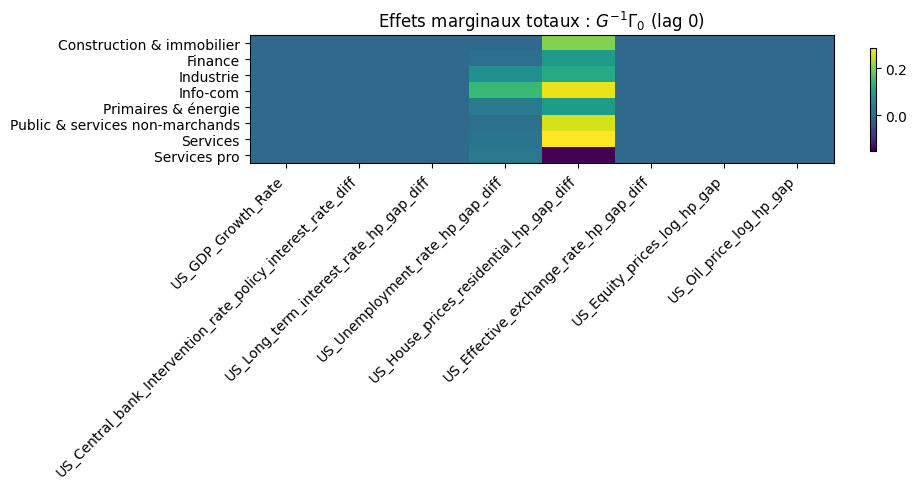

In [110]:
def plot_heatmap(df, title):
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(df.values, aspect="auto")
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index)
    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(df.columns, rotation=45, ha="right")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

# Exemple : effet marginal total à l=0 (impact immédiat)
plot_heatmap(tildeGamma[0], "Effets marginaux totaux : $G^{-1}\\Gamma_0$ (lag 0)")

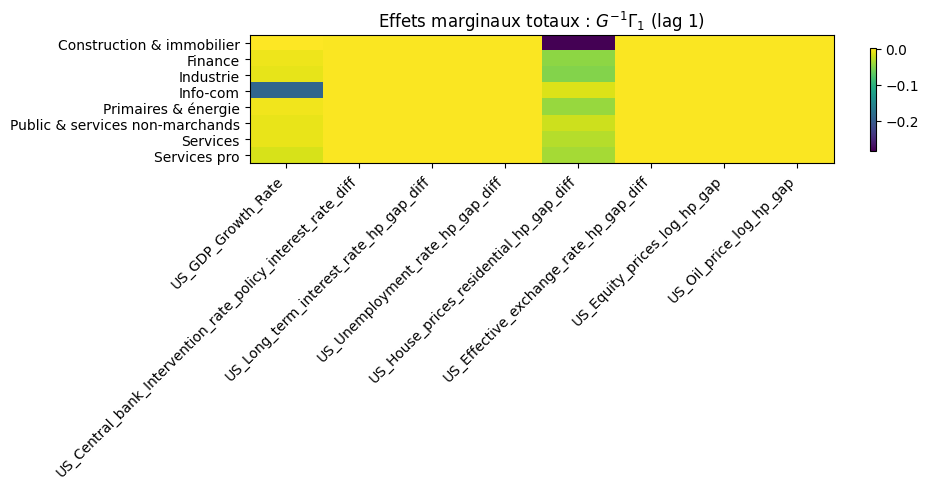

In [111]:
# Exemple : effet marginal total à l=1 (impact à 1 an)
plot_heatmap(tildeGamma[1], "Effets marginaux totaux : $G^{-1}\\Gamma_1$ (lag 1)")

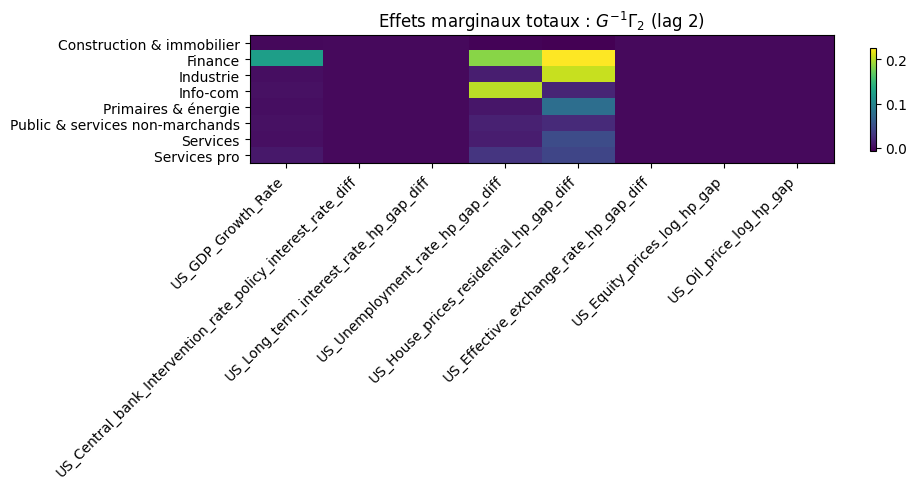

In [112]:
# Exemple : effet marginal total à l=2 (impact à 2 ans)
plot_heatmap(tildeGamma[2], "Effets marginaux totaux : $G^{-1}\\Gamma_2$ (lag 2)")

In [113]:
def spatial_decomposition(B0: np.ndarray, Gamma_l: np.ndarray, k_max=10, tol=1e-10):
    """
    Renvoie la liste [B0^0 Gamma_l, B0^1 Gamma_l, ..., B0^k Gamma_l]
    où chaque terme est (N,K).
    """
    N, K = Gamma_l.shape
    out = []
    Bk = np.eye(N)
    for k in range(k_max + 1):
        term = Bk @ Gamma_l
        out.append(term)
        if k > 0 and np.max(np.abs(term)) < tol:
            break
        Bk = Bk @ B0
    return out

B0 = B[0].values
Gamma0 = Gamma[0].values  # ou Gamma[l].values

terms_l0 = spatial_decomposition(B0, Gamma0, k_max=12)  # liste de (N,K)

In [114]:
terms_l1 = spatial_decomposition(B0, Gamma[1].values, k_max=12)
terms_l2 = spatial_decomposition(B0, Gamma[2].values, k_max=12)
terms_l3 = spatial_decomposition(B0, Gamma[3].values, k_max=12)
terms_l4 = spatial_decomposition(B0, Gamma[4].values, k_max=12) 

In [115]:
import matplotlib.pyplot as plt
def plot_spatial_for_one(sector, macro, terms, sectors, macros, cumulative=True):
    i = sectors.index(sector)
    j = macros.index(macro)
    vals = np.array([t[i, j] for t in terms])
    if cumulative:
        vals = np.cumsum(vals)
        ylabel = "Effet marginal cumulé"
    else:
        ylabel = "Contribution par voisinage k"
    plt.figure(figsize=(9,4))
    plt.plot(range(len(vals)), vals)
    plt.title(f"Décomposition spatiale (macro={macro}) sur {sector}")
    plt.xlabel("Ordre de voisinage k")
    plt.ylabel(ylabel)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

sectors = list(W.index)
macros = list(Gamma[0].columns)

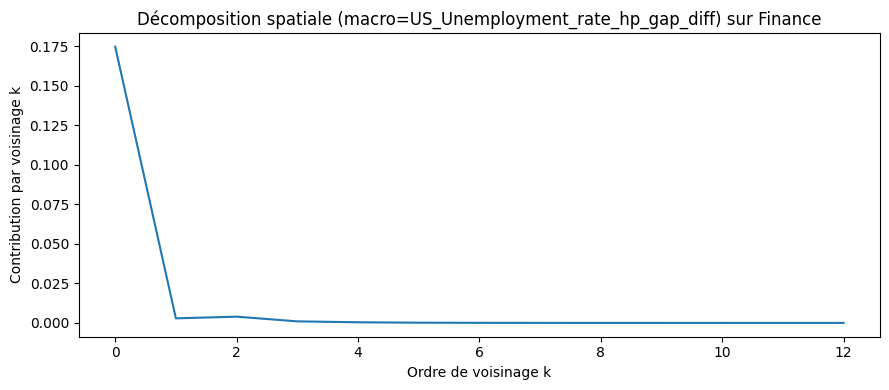

In [116]:
plot_spatial_for_one("Finance", macros[3], terms_l2, sectors, macros, cumulative=False)

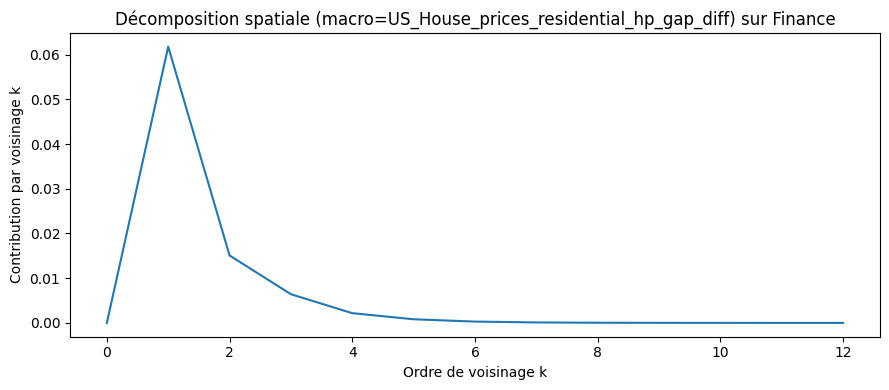

In [117]:
plot_spatial_for_one("Finance", macros[4], terms_l0, sectors, macros, cumulative=False)

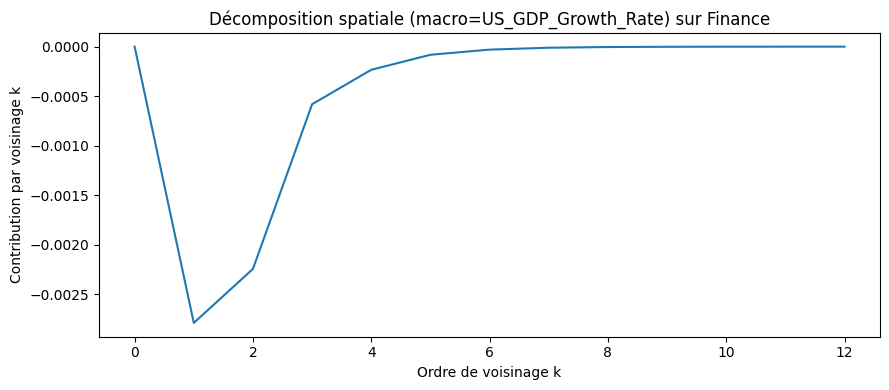

In [118]:
plot_spatial_for_one("Finance", macros[0], terms_l1, sectors, macros, cumulative=False)

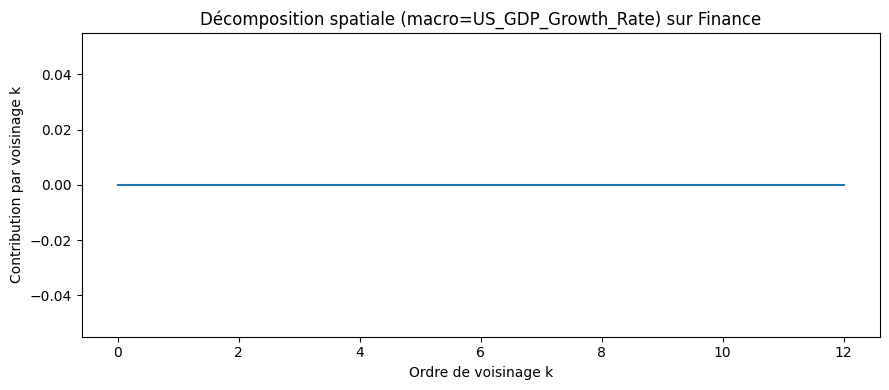

In [119]:
plot_spatial_for_one("Finance", macros[0], terms_l3, sectors, macros, cumulative=False)

######################################################################################################################

# TEST DE VALIDITE DE LA MATRICE W (LR Ttest)

In [120]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

In [129]:
# Z doit déjà contenir les secteurs (même ordre que W.index)
Z_hist = Z[sectors].dropna().copy()

In [136]:
Z_hist.head()

sector,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro
year_quarter,,,,,,,,
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358
2011-01-01,1.428445,-2.079168,0.798452,-0.435846,0.751486,-0.815319,-1.175695,-2.016439
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439
2011-07-01,1.929722,-1.649227,-0.020633,-0.246125,1.030703,0.218599,-0.750586,-2.016439


In [130]:
X_hist = pd.read_csv("data/macro_data/df_macro_stationary1.csv")

In [138]:
X_hist.head()

,date,US_Central_bank_Intervention_rate_policy_interest_rate,US_Effective_exchange_rate,US_Equity_prices,US_GDP_Growth_Rate,US_House_prices_residential,US_Inflation_rate,US_Long_term_interest_rate,US_Oil_price,US_Unemployment_rate
0,2010-01-01,0.125,84.740000,46.875171,0.484501,94.481014,2.360525,3.716667,76.674837,9.833333
1,2010-04-01,0.125,86.106667,41.314746,0.967586,93.876843,1.767765,3.490000,78.845036,9.633333
2,2010-07-01,0.125,84.923333,45.743602,0.771085,92.137491,1.175609,2.786667,76.675000,9.466666
3,2010-10-01,0.125,81.390000,50.410959,0.525110,90.641295,1.270248,2.863333,87.033160,9.500000
4,2011-01-01,0.125,80.343333,53.144269,-0.237205,87.908116,2.141127,3.460000,105.369424,9.033334


In [139]:
import numpy as np
import pandas as pd

# --- X_hist : passer la colonne date en index datetime ---
X_hist2 = X_hist.copy()

# si ta colonne s'appelle bien "date"
X_hist2["date"] = pd.to_datetime(X_hist2["date"])
X_hist2 = X_hist2.set_index("date").sort_index()

# garder uniquement les colonnes numériques (stationnarisées)
X_hist2 = X_hist2.select_dtypes(include=[np.number])

# --- aligner sur l'index trimestriel de Z_hist ---
Z_hist2 = Z_hist.copy()
Z_hist2.index = pd.to_datetime(Z_hist2.index)  # sécurité

X_aligned = X_hist2.reindex(Z_hist2.index)

print("NaN après reindex (total):", int(X_aligned.isna().sum().sum()))
print("Z range:", Z_hist2.index.min(), "->", Z_hist2.index.max())
print("X range:", X_hist2.index.min(), "->", X_hist2.index.max())

NaN après reindex (total): 0
Z range: 2010-07-01 00:00:00 -> 2023-01-01 00:00:00
X range: 2010-01-01 00:00:00 -> 2025-01-01 00:00:00


In [140]:
def build_lagged_data(Z, X, P_star, L):
    # aligner X sur Z (mêmes dates)
    X = X.reindex(Z.index)

    # forcer numérique
    Z = Z.apply(pd.to_numeric, errors="coerce")
    X = X.apply(pd.to_numeric, errors="coerce")

    df = pd.concat([Z, X], axis=1)

    # lags Z (p=1..P_star)
    for p in range(1, P_star + 1):
        for c in Z.columns:
            df[f"{c}_L{p}"] = Z[c].shift(p)

    # lags X (l=0..L)
    for l in range(0, L + 1):
        for c in X.columns:
            df[f"{c}_XL{l}"] = X[c].shift(l)

    df = df.dropna()

    Z_t = df[Z.columns]

    Z_lag_cols = [f"{c}_L{p}" for p in range(1, P_star + 1) for c in Z.columns]
    X_lag_cols = [f"{c}_XL{l}" for l in range(0, L + 1) for c in X.columns]

    Z_lag = df[Z_lag_cols]
    X_lag = df[X_lag_cols]

    return Z_t, Z_lag, X_lag

Z_t, Z_lag, X_lag = build_lagged_data(Z_hist2, X_aligned, P_star, L)

print("Shapes:", Z_t.shape, Z_lag.shape, X_lag.shape)
print("Index aligned?", Z_t.index.equals(Z_lag.index) and Z_t.index.equals(X_lag.index))

Shapes: (47, 8) (47, 32) (47, 45)
Index aligned? True


In [142]:
import statsmodels.api as sm

def compute_Zstar_from_Zlag(Z_lag, W, sectors, p):
    """
    Construit ZstarL{p} à partir de Z_lag (colonnes "sector_Lp")
    """
    # reconstruire une matrice (T,N) de Z_{t-p}
    Zp = pd.DataFrame(index=Z_lag.index, columns=sectors, dtype=float)
    for s in sectors:
        Zp[s] = Z_lag[f"{s}_L{p}"].values

    Zstarp = Zp @ W.T
    Zstarp.columns = [f"{s}_ZstarL{p}" for s in sectors]
    return Zstarp

def estimate_GVAR_from_lagged(Z_t, Z_lag, X_lag, W, P_star):
    sectors = list(Z_t.columns)
    residuals = []

    # on construit ZstarL1..ZstarLP_star sur le même index que Z_t
    Zstar_lags = []
    for p in range(1, P_star + 1):
        Zstar_lags.append(compute_Zstar_from_Zlag(Z_lag, W, sectors, p))
    Zstar_lags = pd.concat(Zstar_lags, axis=1)

    for s in sectors:
        Zstar_cols_s = [f"{s}_ZstarL{p}" for p in range(1, P_star + 1)]
        Xreg = pd.concat([Zstar_lags[Zstar_cols_s], X_lag], axis=1)

        Xreg = Xreg.apply(pd.to_numeric, errors="coerce").dropna()
        y = Z_t.loc[Xreg.index, s]

        Xreg = sm.add_constant(Xreg)
        model = sm.OLS(y.values, Xreg.values).fit()

        residuals.append(model.resid)

    return np.column_stack(residuals)

In [143]:
def estimate_VARX_unrestricted(Z_t, Z_lag, X_lag):
    sectors = list(Z_t.columns)
    residuals = []

    for s in sectors:
        # toutes les colonnes Z_{j,t-p} sauf celles du secteur s, pour tous p
        cols = [c for c in Z_lag.columns if not c.startswith(s + "_")]
        Xreg = pd.concat([Z_lag[cols], X_lag], axis=1)

        Xreg = Xreg.apply(pd.to_numeric, errors="coerce").dropna()
        y = Z_t.loc[Xreg.index, s]

        Xreg = sm.add_constant(Xreg)
        model = sm.OLS(y.values, Xreg.values).fit()

        residuals.append(model.resid)

    return np.column_stack(residuals)

In [144]:
def loglikelihood(residuals):
    T = residuals.shape[0]
    Sigma = residuals.T @ residuals / T
    sign, logdet = np.linalg.slogdet(Sigma)
    if sign <= 0:
        # sécurité numérique
        return -np.inf
    return -T/2 * logdet

def LR_stat(res_VAR, res_GVAR):
    logL_VAR = loglikelihood(res_VAR)
    logL_GVAR = loglikelihood(res_GVAR)
    return -2 * (logL_GVAR - logL_VAR)

def wild_weights(T):
    p = (np.sqrt(5)+1)/(2*np.sqrt(5))
    w1 = (1-np.sqrt(5))/2
    w2 = (1+np.sqrt(5))/2
    u = np.random.rand(T)
    return np.where(u < p, w1, w2)

def bootstrap_LR(Z_t, Z_lag, X_lag, W, P_star, B=500, seed=0):
    rng = np.random.default_rng(seed)

    res_VAR = estimate_VARX_unrestricted(Z_t, Z_lag, X_lag)
    res_GVAR = estimate_GVAR_from_lagged(Z_t, Z_lag, X_lag, W, P_star)

    LR_obs = LR_stat(res_VAR, res_GVAR)

    T = res_GVAR.shape[0]
    LR_boot = np.empty(B)

    for b in range(B):
        # poids wild bootstrap
        u = rng.random(T)
        p = (np.sqrt(5)+1)/(2*np.sqrt(5))
        w1 = (1-np.sqrt(5))/2
        w2 = (1+np.sqrt(5))/2
        k = np.where(u < p, w1, w2)

        e_boot = res_GVAR * k[:, None]

        # bootstrap sample: Z*_boot = fitted_GVAR + e_boot
        # version simple: on conserve les regressors fixes et on bootstrape y = yhat + e*
        # => on reconstruit y_boot secteur par secteur via la régression GVAR
        Z_boot = Z_t.copy()
        Z_boot.iloc[:, :] = Z_t.values + e_boot  # approximation simple (souvent OK en wild bootstrap)

        res_VAR_b = estimate_VARX_unrestricted(Z_boot, Z_lag, X_lag)
        res_GVAR_b = estimate_GVAR_from_lagged(Z_boot, Z_lag, X_lag, W, P_star)

        LR_boot[b] = LR_stat(res_VAR_b, res_GVAR_b)

    p_value = np.mean(LR_boot >= LR_obs)
    return LR_obs, p_value, LR_boot

In [145]:
LR_obs, pval, LR_boot = bootstrap_LR(Z_t, Z_lag, X_lag, W, P_star, B=1000, seed=42)
print("LR_obs =", LR_obs)
print("bootstrap p-value =", pval)

LR_obs = 1144.0640781767397
bootstrap p-value = 0.997


LR_obs = 1144.0640781767397
LR_boot: min/mean/median/max = 1136.4385599043708 1223.9406760383285 1224.5551642502523 1326.570526330066


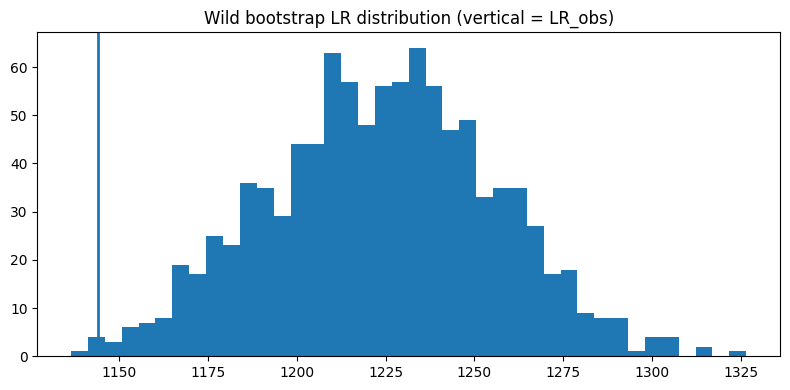

In [146]:
print("LR_obs =", LR_obs)
print("LR_boot: min/mean/median/max =", np.min(LR_boot), np.mean(LR_boot), np.median(LR_boot), np.max(LR_boot))

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(LR_boot, bins=40)
plt.axvline(LR_obs, linewidth=2)
plt.title("Wild bootstrap LR distribution (vertical = LR_obs)")
plt.grid(False)
plt.tight_layout()
plt.show()

In [147]:
res_VAR = estimate_VARX_unrestricted(Z_t, Z_lag, X_lag)
res_GVAR = estimate_GVAR_from_lagged(Z_t, Z_lag, X_lag, W, P_star)

logL_VAR = loglikelihood(res_VAR)
logL_GVAR = loglikelihood(res_GVAR)

print("logL_VAR =", logL_VAR, "| logL_GVAR =", logL_GVAR)
print("LR_obs =", -2*(logL_GVAR - logL_VAR))

logL_VAR = 11967.670425190583 | logL_GVAR = 11395.638386102213
LR_obs = 1144.0640781767397


Bootstrap corrigé

In [148]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def mammen_weights(T, rng):
    p = (np.sqrt(5)+1)/(2*np.sqrt(5))
    w1 = (1-np.sqrt(5))/2
    w2 = (1+np.sqrt(5))/2
    u = rng.random(T)
    return np.where(u < p, w1, w2)

def fit_gvar_sectorwise(Z_t, Z_lag, X_lag, W, P_star):
    sectors = list(Z_t.columns)

    # construire Zstar lags
    Zstar_lags = []
    for p in range(1, P_star + 1):
        Zp = pd.DataFrame({s: Z_lag[f"{s}_L{p}"] for s in sectors}, index=Z_lag.index)
        Zstarp = Zp @ W.T
        Zstarp.columns = [f"{s}_ZstarL{p}" for s in sectors]
        Zstar_lags.append(Zstarp)
    Zstar_lags = pd.concat(Zstar_lags, axis=1)

    fits = {}
    yhat = pd.DataFrame(index=Z_t.index, columns=sectors, dtype=float)
    resid = pd.DataFrame(index=Z_t.index, columns=sectors, dtype=float)

    for s in sectors:
        Xreg = pd.concat(
            [Zstar_lags[[f"{s}_ZstarL{p}" for p in range(1, P_star + 1)]], X_lag],
            axis=1
        )
        Xreg = Xreg.apply(pd.to_numeric, errors="coerce")
        y = Z_t[s].loc[Xreg.index]
        Xreg = sm.add_constant(Xreg)

        model = sm.OLS(y.values, Xreg.values).fit()
        fits[s] = (model, Xreg.index, Xreg)  # on garde pour reconstruire
        yhat.loc[Xreg.index, s] = model.fittedvalues
        resid.loc[Xreg.index, s] = model.resid

    yhat = yhat.dropna()
    resid = resid.loc[yhat.index]
    return yhat, resid

def bootstrap_LR_proper(Z_t, Z_lag, X_lag, W, P_star, B=500, seed=42):
    rng = np.random.default_rng(seed)

    # Résidus et fitted sous H0 (GVAR)
    yhat, ehat = fit_gvar_sectorwise(Z_t, Z_lag, X_lag, W, P_star)
    idx = yhat.index

    # Résidus des deux modèles sur l'échantillon commun
    Zt0 = Z_t.loc[idx]
    Zlag0 = Z_lag.loc[idx]
    Xlag0 = X_lag.loc[idx]

    res_VAR0 = estimate_VARX_unrestricted(Zt0, Zlag0, Xlag0)
    res_GVAR0 = estimate_GVAR_from_lagged(Zt0, Zlag0, Xlag0, W, P_star)
    LR_obs = LR_stat(res_VAR0, res_GVAR0)

    T = len(idx)
    LR_boot = np.empty(B)

    for b in range(B):
        k = mammen_weights(T, rng)
        Z_boot = yhat + ehat.mul(k, axis=0)  # y* = yhat + k*ehat

        res_VAR_b = estimate_VARX_unrestricted(Z_boot, Zlag0, Xlag0)
        res_GVAR_b = estimate_GVAR_from_lagged(Z_boot, Zlag0, Xlag0, W, P_star)
        LR_boot[b] = LR_stat(res_VAR_b, res_GVAR_b)

    pval = np.mean(LR_boot >= LR_obs)
    return LR_obs, pval, LR_boot

In [149]:
LR_obs2, pval2, LR_boot2 = bootstrap_LR_proper(Z_t, Z_lag, X_lag, W, P_star, B=1000, seed=7)
print("LR_obs =", LR_obs2)
print("p-value bootstrap (proper) =", pval2)

LR_obs = 1144.0640781767397
p-value bootstrap (proper) = 0.952


###################################################################################################################

In [ ]:
# Z doit déjà contenir les secteurs (même ordre que W.index)
Z_hist = Z[sectors].dropna().copy()

In [ ]:
Z_hist

In [ ]:
import matplotlib.pyplot as plt
sector = "Finance"
plt.figure(figsize=(8,4))
plt.plot(Z_hist.index, Z_hist[sector])
plt.title("Finance — historique uniquement")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
Z_init = Z_hist.iloc[-P_star:].copy()

In [ ]:
Z_init

In [ ]:
print(Z_init.shape)        # doit être (P_star, N)
print(Z_init.columns)      # doit être exactement W.index
print(Z_init.index)        # dernières dates historiques

In [ ]:
# X_scenario : index = dates, colonnes = macros (K)
X_scenario = X_scenario
X_scenario.index = pd.to_datetime(X_scenario.index)

last_hist_date = pd.to_datetime(Z_hist.index[-1])

# Garder uniquement les dates futures
X_scenario_future = X_scenario[X_scenario.index >= last_hist_date].copy()

print("Last hist:", last_hist_date)
print("Scenario start:", X_scenario_future.index[0] if len(X_scenario_future)>0 else None)
print("Scenario shape:", X_scenario_future.shape)

In [ ]:
print("---- CHECK DIMENSIONS ----")
print("P_star =", P_star)
print("L =", L)

print("Z_init shape:", Z_init.shape)
print("Z_init columns:", Z_init.columns)

print("F keys:", F.keys())
print("F[1] shape:", F[1].shape if P_star >= 1 else None)

print("tildeGamma keys:", tildeGamma.keys())
print("tildeGamma[0] shape:", tildeGamma[0].shape)

print("X_future shape:", X_scenario_future.shape)
print("X_future columns:", X_scenario_future.columns)

print("Nb sectors:", len(Z_init.columns))
print("Nb macros:", len(X_scenario_future.columns))

In [ ]:
X_scenario_future.columns

In [ ]:
macro_cols

In [ ]:
from statsmodels.tsa.filters.hp_filter import hpfilter
import numpy as np
import pandas as pd

def hp_gap(series, lamb=1600):
    s = series.astype(float)
    cycle, trend = hpfilter(s.dropna(), lamb=lamb)
    return cycle.reindex(series.index)

def safe_log(series):
    s = series.astype(float)
    return np.log(s.where(s > 0))

def transform_macro_dataset(df_raw):
    """
    Applique exactement les mêmes transformations que pour l'estimation.
    Retourne un DataFrame transformé.
    """

    df = df_raw.copy()

    # --- HP gaps ---
    df["US_Unemployment_rate_hp_gap"] = hp_gap(df["US_Unemployment_rate"])
    df["US_Unemployment_rate_hp_gap_diff"] = df["US_Unemployment_rate_hp_gap"].diff()

    df["US_Long_term_interest_rate_hp_gap"] = hp_gap(df["US_Long_term_interest_rate"])
    df["US_Long_term_interest_rate_hp_gap_diff"] = \
        df["US_Long_term_interest_rate_hp_gap"].diff()

    df["US_House_prices_residential_hp_gap"] = hp_gap(df["US_House_prices_residential"])
    df["US_House_prices_residential_hp_gap_diff"] = df["US_House_prices_residential_hp_gap"].diff()

    df["US_Effective_exchange_rate_hp_gap"] = hp_gap(df["US_Effective_exchange_rate"])
    df["US_Effective_exchange_rate_hp_gap_diff"] = df["US_Effective_exchange_rate_hp_gap"].diff()

    # --- Diff directe ---
    df["US_Central_bank_Intervention_rate_policy_interest_rate_diff"] = \
        df["US_Central_bank_Intervention_rate_policy_interest_rate"].diff()

    # --- Logs + HP ---
    df["US_Equity_prices_log"] = safe_log(df["US_Equity_prices"])
    df["US_Equity_prices_log_hp_gap"] = hp_gap(df["US_Equity_prices_log"])

    df["US_Oil_price_log"] = safe_log(df["US_Oil_price"])
    df["US_Oil_price_log_hp_gap"] = hp_gap(df["US_Oil_price_log"])

    df["US_GDP_log"] = safe_log(df["US_GDP_Growth_Rate"])
    df["US_GDP_log_hp_gap"] = hp_gap(df["US_GDP_log"])
    df["US_GDP_log_hp_gap_diff"] = df["US_GDP_log_hp_gap"].diff()

    return df

In [ ]:
X_hist = pd.read_csv("data/macro_data/df_macro_stationary1.csv")

In [ ]:
X_full = pd.concat([X_hist, X_scenario_future])
X_full_transformed = transform_macro_dataset(X_full)

# ensuite séparer
X_scenario_transformed = X_full_transformed.loc[X_scenario_future.index]

In [ ]:
macro_cols = list(tildeGamma[0].columns)

In [ ]:
X_scenario_final = X_scenario_transformed[macro_cols].copy()

In [ ]:
import pandas as pd
import numpy as np

def project_gvar(Z_init, X_scenario, mu, F, tildeGamma, P_star, L):
    """
    Z_init: DataFrame (P_star x N) dernières valeurs observées, colonnes=secteurs
    X_scenario: DataFrame (H x K) index=dates, colonnes=macro_cols (sans 'date' en colonne)
    mu: array (N,1)
    F: dict p-> DataFrame (N x N), p=1..P_star
    tildeGamma: dict l-> DataFrame (N x K), l=0..L
    """
    sectors = list(Z_init.columns)
    N = len(sectors)
    H = len(X_scenario)

    # On garde un historique avec les bonnes colonnes
    Z_lags = Z_init.copy()

    projections = []

    for h in range(H):
        z_new = mu.copy()

        # dynamique sectorielle
        for p in range(1, P_star + 1):
            z_lag = Z_lags.iloc[-p][sectors].values.reshape(N, 1)
            z_new += F[p].values @ z_lag

        # bloc macro
        for l in range(0, L + 1):
            if h - l >= 0:
                x_val = X_scenario.iloc[h - l].values.reshape(-1, 1)
                z_new += tildeGamma[l].values @ x_val

        # stocker projection
        projections.append(z_new.ravel())

        # AJOUTER UNE LIGNE avec les MÊMES colonnes
        new_row = pd.DataFrame([z_new.ravel()], columns=sectors, index=[X_scenario.index[h]])
        Z_lags = pd.concat([Z_lags, new_row], axis=0)

    Z_proj = pd.DataFrame(projections, index=X_scenario.index, columns=sectors)
    return Z_proj

In [ ]:
Z_proj_baseline = project_gvar(
    Z_init,
    X_scenario_final,
    mu,
    F,
    tildeGamma,
    P_star,
    L
)

print("Z_proj_baseline:", Z_proj_baseline.shape)
Z_proj_baseline.head()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sector ="Finance"

y_hist = Z_hist[sector].values
ymin, ymax = np.nanpercentile(y_hist, [1, 99])   # robustes aux outliers
pad = 0.2 * (ymax - ymin)

plt.figure(figsize=(10,5))
plt.plot(Z_hist.index, Z_hist[sector], label="Historique")
plt.plot(Z_proj_baseline.index, Z_proj_baseline[sector], "--", label="Projection baseline")
plt.axvline(Z_hist.index[-1], color="black", linestyle=":")

plt.ylim(ymin - pad, ymax + pad)  # 👈 fixe l’échelle selon l’historique
plt.title(f"{sector} — Historique & projection (zoom hist)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

N = len(sectors)
P = P_star

# Companion matrix
top = np.hstack([F[p].values for p in range(1, P+1)])        # (N, N*P)
bottom = np.eye(N*(P-1), N*P)                                # (N*(P-1), N*P)
companion = np.vstack([top, bottom])                         # (N*P, N*P)

eigvals = np.linalg.eigvals(companion)
print("Max |eig| =", np.max(np.abs(eigvals)))

L’estimation OLS initiale produisait une dynamique instable (rayon spectral > 1), entraînant des projections explosives à long horizon.
Nous avons donc utilisé une estimation Ridge afin de régulariser les coefficients et garantir la stabilité dynamique du système (max |λ| < 1).
Cette approche est standard dans les modèles macro-financiers à forte dimension

In [ ]:
sector = "Finance"

# Historique
hist_dates = Z_hist.index
hist_values = Z_hist[sector]

# Projection
proj_dates = Z_proj_baseline.index
proj_values = Z_proj_baseline[sector]

plt.figure(figsize=(10,5))

# Historique
plt.plot(hist_dates, hist_values, 
         color="#1f77b4", linewidth=2, label="Historique")

# Projection (ligne pleine, plus fine)
plt.plot(proj_dates, proj_values, 
         color="#d62728", linewidth=2, label="Projection baseline")

# Ligne verticale séparation
plt.axvline(hist_dates[-1], color="black", linestyle=":", linewidth=1.5)

# Zone projection grisée
plt.axvspan(hist_dates[-1], proj_dates[-1], 
            color="grey", alpha=0.08)

plt.title(f"{sector} — Historique et projection baseline", fontsize=13)
plt.ylabel("Facteur sectoriel")
plt.xlabel("Date")

plt.legend(frameon=False)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# concaténer pour une ligne continue
combined = pd.concat([hist_values, proj_values])

plt.figure(figsize=(10,5))
plt.plot(combined.index, combined.values,
         color="#1f77b4", linewidth=2)

plt.axvline(hist_dates[-1], color="black", linestyle=":", linewidth=1.5)
plt.axvspan(hist_dates[-1], proj_dates[-1], color="grey", alpha=0.08)

plt.title(f"{sector} — Dynamique projetée", fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.style.use("seaborn-v0_8-whitegrid")

Et les autres scénarios 

In [ ]:
X_Zero = pd.read_csv("data/ngfs_data/X_Net_Zero_2050.csv")

In [ ]:
X_Zero = X_Zero.set_index("date")

In [ ]:
X_Zero.columns

In [ ]:
X_Zero.index = pd.to_datetime(X_Zero.index)

In [ ]:
# Garder uniquement les dates futures
X_Zero_future = X_Zero[X_Zero.index >= last_hist_date].copy()

In [ ]:
X_full_zero = pd.concat([X_hist, X_Zero_future])
X_full_transformed_zero = transform_macro_dataset(X_full_zero)

# ensuite séparer
X_zero_transformed = X_full_transformed_zero.loc[X_Zero_future.index]

In [ ]:
import pandas as pd

def project_one_scenario(
    scenario_csv_path,
    scenario_name,
    X_hist_raw,
    macro_cols,
    transform_func,
    last_hist_date,
    Z_init,
    mu,
    F,
    tildeGamma,
    P_star,
    L
):
    """
    Charge un scénario, applique transformations cohérentes,
    projette le GVAR et retourne la projection sectorielle.
    """

    # 1️⃣ Charger scénario brut
    X_scen = pd.read_csv(scenario_csv_path)
    X_scen = X_scen.set_index("date")
    X_scen.index = pd.to_datetime(X_scen.index)

    # 2️⃣ Garder uniquement futur
    X_future_raw = X_scen[X_scen.index >= last_hist_date].copy()

    # 3️⃣ Concat historique + futur (important pour HP filter)
    X_full = pd.concat([X_hist_raw, X_future_raw])

    # 4️⃣ Appliquer mêmes transformations
    X_full_transformed = transform_func(X_full)

    # 5️⃣ Extraire partie future transformée
    X_future_transformed = X_full_transformed.loc[X_future_raw.index]

    # 6️⃣ Garder uniquement colonnes du modèle
    X_future_final = X_future_transformed[macro_cols].copy()

    # 7️⃣ Projection GVAR
    Z_proj = project_gvar(
        Z_init,
        X_future_final,
        mu,
        F,
        tildeGamma,
        P_star,
        L
    )

    print(f"✔ Projection terminée : {scenario_name}")

    return Z_proj

In [ ]:
scenario_files = {
    "Baseline": "data/ngfs_data/X_Baseline.csv",
    "Below 2°C": "data/ngfs_data/X_Below_2C.csv",
    "Current Policies": "data/ngfs_data/X_Current_Policies.csv",
    "Delayed Transition": "data/ngfs_data/X_Delayed_transition.csv",
    "Fragmented World": "data/ngfs_data/X_Fragmented_World.csv",
    "NDC": "data/ngfs_data/X_Nationally_Determined_Contribut.csv",
    "Net Zero 2050": "data/ngfs_data/X_Net_Zero_2050.csv"
}

Z_projections = {}

for scen_name, scen_path in scenario_files.items():
    Z_projections[scen_name] = project_one_scenario(
        scenario_csv_path=scen_path,
        scenario_name=scen_name,
        X_hist_raw=X_hist,                     # macro historique brute
        macro_cols=macro_cols,
        transform_func=transform_macro_dataset,
        last_hist_date=last_hist_date,
        Z_init=Z_init,
        mu=mu,
        F=F,
        tildeGamma=tildeGamma,
        P_star=P_star,
        L=L
    )

In [ ]:
import matplotlib.pyplot as plt

def plot_sector_scenarios(sector, Z_hist, Z_projections):

    plt.figure(figsize=(11,6))

    # Historique
    plt.plot(Z_hist.index, Z_hist[sector],
             color="black", linewidth=2.5, label="Historique")

    # Projections
    for scen_name, Z_proj in Z_projections.items():
        plt.plot(Z_proj.index, Z_proj[sector],
                 linewidth=2, label=scen_name)

    # Séparation
    plt.axvline(Z_hist.index[-1], color="black", linestyle=":", linewidth=1.5)

    plt.title(f"{sector} — Comparaison des scénarios NGFS", fontsize=14)
    plt.ylabel("Facteur sectoriel")
    plt.xlabel("Date")
    plt.legend(frameon=False)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_sector_scenarios(
    sector="Industrie",
    Z_hist=Z_hist,
    Z_projections=Z_projections
)

In [ ]:
plot_sector_scenarios(
    sector="Finance",
    Z_hist=Z_hist,
    Z_projections=Z_projections
)

In [ ]:
plot_sector_scenarios(
    sector="Extractions primaire",
    Z_hist=Z_hist,
    Z_projections=Z_projections
)

################# fin 3 

In [ ]:
Z_tilde = Z_hist - Z_hist.mean()
X_tilde = X - X.mean()

Z_tilde.head()

In [ ]:

N = len(sectors)
P = P_star

top = np.hstack([F[p].values for p in range(1, P+1)])
bottom = np.eye(N*(P-1), N*P)

companion = np.vstack([top, bottom])

eigvals = np.linalg.eigvals(companion)

print("Max |eig| =", np.max(np.abs(eigvals)))

In [ ]:
def compute_phi_matrices(F, H=10):
    
    Phi = {}
    N = F[1].shape[0]
    
    Phi[0] = np.eye(N)
    
    for h in range(1, H+1):
        Phi[h] = np.zeros((N, N))
        for p in range(1, min(P_star, h) + 1):
            Phi[h] += Phi[h-p] @ F[p].values
            
    return Phi

H = 10  # horizon GIRF
Phi = compute_phi_matrices(F, H=H)

In [ ]:
def build_regression_dataset(df_all, sector, Pmax=4, Lmax=4):
    
    df = pd.DataFrame(index=df_all.index)

    # variable dépendante
    df["y"] = df_all[sector]

    # Zstar lags
    for p in range(Pmax+1):
        df[f"ZstarL{p}"] = df_all[f"{sector}_star"].shift(p)

    # macro lags
    for col in macro_cols:
        for l in range(Lmax+1):
            df[f"X_L{l}_{col}"] = df_all[col].shift(l)

    df["const"] = 1.0

    return df.dropna()

In [ ]:
from sklearn.linear_model import Ridge

def build_residuals_df_ridge(df_all, sectors, coef_df, Pmax=4, Lmax=4, alpha=10.0):

    residuals = {}

    for s in sectors:

        df_reg = build_regression_dataset(df_all, s, Pmax, Lmax)

        kept_cols = coef_df.loc[s].dropna().index.tolist()

        if "const" not in kept_cols:
            kept_cols = ["const"] + kept_cols

        y = df_reg["y"].values
        X = df_reg[kept_cols].values

        model = Ridge(alpha=alpha, fit_intercept=False)
        model.fit(X, y)

        yhat = model.predict(X)
        resid = y - yhat

        residuals[s] = pd.Series(resid, index=df_reg.index)

    residuals_df = pd.DataFrame(residuals).dropna()
    residuals_df = residuals_df[sectors]

    return residuals_df

In [ ]:
residuals_df = build_residuals_df_ridge(
    df_all,
    sectors,
    coef_df,
    Pmax=4,
    Lmax=4,
    alpha=10.0
)

print(residuals_df.shape)
residuals_df.head()

In [ ]:
residuals = residuals_df.values   # dataframe des résidus empilés

Sigma_eps = np.cov(residuals.T)

Sigma_eps

In [ ]:

Sigma_eta = Ginv @ Sigma_eps @ Ginv.T

Sigma_eta

In [ ]:


def compute_girf(Phi, Sigma_eta, shock_index, H=10):
    
    N = Sigma_eta.shape[0]
    e_j = np.zeros(N)
    e_j[shock_index] = 1
    
    sigma_jj = Sigma_eta[shock_index, shock_index]
    
    girf = []
    
    for h in range(H+1):
        response = Phi[h] @ Sigma_eta @ e_j / np.sqrt(sigma_jj)
        girf.append(response)
        
    return np.array(girf)

# Exemple : choc sur Industrie lourde
shock_sector = "Industrie"
shock_index = sectors.index(shock_sector)

girf_industrie = compute_girf(Phi, Sigma_eta, shock_index, H=10)

In [ ]:


affected_sectors = ["Info-com", "Industrie", 
                    "Construction & immobilier", 
                    "Finance"]

plt.figure(figsize=(9,5))

for s in affected_sectors:
    idx = sectors.index(s)
    plt.plot(range(H+1), girf_industrie[:, idx], label=s)

plt.axhline(0, color="black", linewidth=1)
plt.title("Réponse impulsionnelle : choc sur Industrie (horizon 10)")
plt.xlabel("Horizon (années)")
plt.ylabel("Effet sur le facteur systémique")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
shock_sector = "Finance"
shock_index = sectors.index(shock_sector)

girf_construction = compute_girf(Phi, Sigma_eta, shock_index, H=10)

In [ ]:
affected_sectors = ["Info-com", "Industrie", 
                    "Construction & immobilier", 
                    "Finance"]

plt.figure(figsize=(9,5))

for s in affected_sectors:
    idx = sectors.index(s)
    plt.plot(range(H+1), girf_construction[:, idx], label=s)

plt.axhline(0, color="black", linewidth=1)
plt.title("Réponse impulsionnelle : choc sur Industrie (horizon 10)")
plt.xlabel("Horizon (années)")
plt.ylabel("Effet sur le facteur systémique")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import os

output_dir = "data/output/Z_projections"
os.makedirs(output_dir, exist_ok=True)

for scen_name, Z_df in Z_projections.items():
    
    # Nettoyer nom pour fichier
    scen_file = scen_name.replace(" ", "_").replace("°", "")
    
    file_path = os.path.join(output_dir, f"Z_{scen_file}.csv")
    
    Z_df_export = Z_df.copy()
    Z_df_export.index.name = "date"
    
    Z_df_export.to_csv(file_path)
    
    print(f"✔ Exporté : {file_path}")

##################################################

Cette partie présente les essaies pour ajuster le modèle ( ne la prend pas en compte)

In [ ]:
def build_design_sector(df_all, sector, P_star, L, macro_cols):
    
    # Variable dépendante
    y = df_all[sector]
    
    X_parts = []
    
    # Z_star lags
    for p in range(0, P_star + 1):
        X_parts.append(df_all[f"{sector}_star"].shift(p).rename(f"ZstarL{p}"))
    
    # Macros lags
    for l in range(0, L + 1):
        X_parts.append(
            df_all[macro_cols].shift(l).add_prefix(f"X_L{l}_")
        )
    
    Xreg = pd.concat(X_parts, axis=1)
    Xreg = sm.add_constant(Xreg, has_constant="add")
    
    df_reg = pd.concat([y.rename("y"), Xreg], axis=1).dropna()
    
    return df_reg

In [ ]:
X.columns

In [ ]:
macro_cols = list(X.columns)

sector = "Finance"

df_reg = build_design_sector(
    df_all=df_all,
    sector=sector,
    P_star=1,
    L=0,
    macro_cols=macro_cols
)

df_reg.head()

In [ ]:
res = sm.OLS(df_reg["y"], df_reg.drop(columns="y")).fit()
print(res.summary())

In [ ]:
def select_lags_sector(df_all, sector, macro_cols,
                       P_grid=(0,1,2,3),
                       L_grid=(0,1,2,3)):
    
    results = []
    
    for P_star in P_grid:
        for L in L_grid:
            
            try:
                df_reg = build_design_sector(df_all, sector, P_star, L, macro_cols)
                res = sm.OLS(df_reg["y"], df_reg.drop(columns="y")).fit()
                
                results.append({
                    "P_star": P_star,
                    "L": L,
                    "BIC": res.bic
                })
            except:
                continue
    
    return pd.DataFrame(results).sort_values("BIC")

In [ ]:
select_lags_sector(
    df_all,
    sector="Finance",
    macro_cols=macro_cols
)

##################################################

In [ ]:
def lag_series(s: pd.Series, max_lag: int, prefix: str) -> pd.DataFrame:
    """Crée les lags 0..max_lag d'une série."""
    out = []
    for l in range(0, max_lag + 1):
        out.append(s.shift(l).rename(f"{prefix}L{l}"))
    return pd.concat(out, axis=1)

def lag_dataframe(df: pd.DataFrame, max_lag: int, prefix: str) -> pd.DataFrame:
    """Crée les lags 0..max_lag de toutes les colonnes d'un DF."""
    out = []
    for l in range(0, max_lag + 1):
        tmp = df.shift(l).add_prefix(f"{prefix}L{l}_")
        out.append(tmp)
    return pd.concat(out, axis=1)


#Estimation OLS secteur par secteur 

In [ ]:
def estimate_sector_varx(
    df_all: pd.DataFrame,
    sector: str,
    macro_cols: list[str],
    P: int,
    P_star: int,
    L: int
):
    """
    Estime: Z_i(t) ~ const + lags(Z_i, 1..P) + lags(Z_i*, 0..P_star) + lags(X, 0..L)
    """
    y = df_all[sector]

    # --- Retards domestiques (1..P)
    X_dom = []
    for p in range(1, P + 1):
        X_dom.append(df_all[sector].shift(p).rename(f"ZL{p}"))

    X_dom = pd.concat(X_dom, axis=1) if X_dom else None

    # --- Retards étrangers (0..P_star)
    star_col = f"{sector}_star"
    X_star = lag_series(df_all[star_col], P_star, prefix="Zstar")  # L0..LP_star

    # --- Retards macro (0..L)
    X_macro = lag_dataframe(df_all[macro_cols], L, prefix="X_") if macro_cols else None

    # --- Assemblage régressions
    X_parts = []
    if X_dom is not None:
        X_parts.append(X_dom)
    X_parts.append(X_star)
    if X_macro is not None:
        X_parts.append(X_macro)

    Xreg = pd.concat(X_parts, axis=1)
    data = pd.concat([y.rename("y"), Xreg], axis=1).dropna()

    y2 = data["y"]
    X2 = sm.add_constant(data.drop(columns=["y"]))
    model = sm.OLS(y2, X2).fit()

    return model

macro_cols = list(X.columns)

models = {}
residuals = {}
coefs = {}

for s in W.index:
    m = estimate_sector_varx(df_all, sector=s, macro_cols=macro_cols, P=P, P_star=P_star, L=L)
    models[s] = m
    residuals[s] = m.resid
    coefs[s] = m.params

# Exemple d'output
first_sector = W.index[0]
print(first_sector)
print(models[first_sector].summary())


In [ ]:
coef_df = pd.DataFrame(coefs).T  # index=secteurs, colonnes=params
coef_df.to_csv(os.path.join(OUTPUT_DIR, "gvar_step1_coef_all.csv"))

resid_df = pd.DataFrame(residuals).dropna()
resid_df.to_csv(os.path.join(OUTPUT_DIR, "gvar_step1_residuals.csv"))

print("Saved:")
print(" -", os.path.join(OUTPUT_DIR, "gvar_step1_coef_all.csv"))
print(" -", os.path.join(OUTPUT_DIR, "gvar_step1_residuals.csv"))

coef_df.head()


# Construction du GVAR 

In [ ]:
def build_B_matrices(W: pd.DataFrame, coef_df: pd.DataFrame, P_star: int):
    """
    Construit B_p pour p=0..P_star à partir des coefficients beta_i,p = coef['ZstarLp'].
    """
    N = W.shape[0]
    sectors = list(W.index)

    # sécurité : diagonale W nulle
    W2 = W.copy()
    np.fill_diagonal(W2.values, 0.0)

    B = {}
    for p in range(0, P_star + 1):
        # vecteur beta_{i,p} pour tous i
        beta_name = f"ZstarL{p}"
        if beta_name not in coef_df.columns:
            raise ValueError(f"Colonne manquante dans coef_df: {beta_name}")

        beta_vec = coef_df.loc[sectors, beta_name].values.reshape(-1, 1)  # (N,1)

        # B_p = diag(beta_vec) * W
        Bp = (beta_vec * W2.values)  # broadcasting ligne i
        np.fill_diagonal(Bp, 0.0)    # imposer (i,i)=0
        B[p] = pd.DataFrame(Bp, index=sectors, columns=sectors)

    return B

B = build_B_matrices(W, coef_df, P_star=P_star)

# Vérifier dimensions
print("B0 shape:", B[0].shape)

# Matrice G = I - B0 (utile si tu as un contemporain)
I = np.eye(W.shape[0])
G = pd.DataFrame(I - B[0].values, index=W.index, columns=W.columns)

# Vérifier inversibilité numérique (conditionnement)
cond_G = np.linalg.cond(G.values)
det_G = np.linalg.det(G.values)

print("det(G) =", det_G)
print("cond(G) =", cond_G)


In [ ]:
def build_Gamma_matrices(coef_df, sectors, macro_cols, L):

    Gamma = {}

    for l in range(0, L+1):

        # noms exacts des colonnes pour ce lag
        cols_l = [f"X_L{l}_{mc}" for mc in macro_cols]

        # vérifier qu'elles existent
        for c in cols_l:
            if c not in coef_df.columns:
                raise ValueError(f"Colonne manquante : {c}")

        Gl = coef_df.loc[sectors, cols_l].values  # matrice m x K

        Gamma[l] = pd.DataFrame(
            Gl,
            index=sectors,
            columns=macro_cols
        )

    return Gamma

In [ ]:
coef_df.columns

In [ ]:
macro_cols = [
    'US_Central_bank_Intervention_rate_policy_interest_rate',
    'US_Effective_exchange_rate',
    'US_Equity_prices',
    'US_GDP_Growth_Rate',
    'US_House_prices_residential',
    'US_Inflation_rate',
    'US_Long_term_interest_rate',
    'US_Oil_price',
    'US_Unemployment_rate'
]

In [ ]:
sectors = list(W.index)

In [ ]:
Gamma = build_Gamma_matrices(
    coef_df=coef_df,
    sectors=sectors,
    macro_cols=macro_cols,
    L=1
)

In [ ]:
Gamma

In [ ]:
G_inv = np.linalg.inv(G_mat.values)

####################

In [ ]:
P1 = 4
L=4

In [ ]:
F = {}

for p in range(1, P1+1):
    F[p] = pd.DataFrame(
        G_inv @ B[p].values,
        index=sectors,
        columns=sectors
    )

In [ ]:
tildeGamma = {}

for l in range(0, L+1):
    tildeGamma[l] = pd.DataFrame(
        G_inv @ Gamma[l].values,
        index=sectors,
        columns=macro_cols
    )

In [ ]:
alpha = coef_df.loc[sectors, "const"].values.reshape(-1,1)

mu = G_inv @ alpha

In [ ]:
eigvals = np.linalg.eigvals(F[1].values)
print(np.abs(eigvals).max())

un modele stable donc ! 

## PRojections 

In [ ]:
import pandas as pd
import numpy as np

def project_gvar(Z_init, X_scenario, mu, F, tildeGamma, P_star, L):
    """
    Z_init: DataFrame (P_star x N) dernières valeurs observées, colonnes=secteurs
    X_scenario: DataFrame (H x K) index=dates, colonnes=macro_cols (sans 'date' en colonne)
    mu: array (N,1)
    F: dict p-> DataFrame (N x N), p=1..P_star
    tildeGamma: dict l-> DataFrame (N x K), l=0..L
    """
    sectors = list(Z_init.columns)
    N = len(sectors)
    H = len(X_scenario)

    # On garde un historique avec les bonnes colonnes
    Z_lags = Z_init.copy()

    projections = []

    for h in range(H):
        z_new = mu.copy()

        # dynamique sectorielle
        for p in range(1, P_star + 1):
            z_lag = Z_lags.iloc[-p][sectors].values.reshape(N, 1)
            z_new += F[p].values @ z_lag

        # bloc macro
        for l in range(0, L + 1):
            if h - l >= 0:
                x_val = X_scenario.iloc[h - l].values.reshape(-1, 1)
                z_new += tildeGamma[l].values @ x_val

        # stocker projection
        projections.append(z_new.ravel())

        # AJOUTER UNE LIGNE avec les MÊMES colonnes
        new_row = pd.DataFrame([z_new.ravel()], columns=sectors, index=[X_scenario.index[h]])
        Z_lags = pd.concat([Z_lags, new_row], axis=0)

    Z_proj = pd.DataFrame(projections, index=X_scenario.index, columns=sectors)
    return Z_proj

In [ ]:
Z_hist = Z[sectors].dropna()

Z_init = Z_hist.iloc[-P_star:].copy()

In [ ]:
Z_init

In [ ]:
print("Nombre secteurs dans W :", len(W.index))
print("Shape F[1] :", F[1].shape)
print("Colonnes Z_init :", len(Z_init.columns))
print("Z_init columns :", Z_init.columns)

In [ ]:
X_scenario=pd.read_csv("data/ngfs_data/ngfs_us.csv")

In [ ]:
X_scenario = X_scenario.set_index("date")

In [ ]:
X_scenario.index = pd.to_datetime(X_scenario.index)

In [ ]:
last_hist_date = Z_hist.index[-1]

X_scenario = X_scenario[X_scenario.index > last_hist_date]

In [ ]:
Z_proj = project_gvar(
    Z_init=Z_init,
    X_scenario=X_scenario,
    mu=mu,
    F=F,
    tildeGamma=tildeGamma,
    P_star=P_star,
    L=L
)

In [ ]:
print(X_scenario.columns)

In [ ]:
Z_hist = Z_hist.copy()
Z_proj = Z_proj.copy()

Z_hist.index = pd.to_datetime(Z_hist.index)
Z_proj.index = pd.to_datetime(Z_proj.index)

In [ ]:
import matplotlib.pyplot as plt

sector_to_plot = "Industrie"  # adapte si besoin

# concat historique + projection
Z_full = pd.concat([Z_hist[sector_to_plot], Z_proj[sector_to_plot]])

plt.figure(figsize=(10,5))

# Historique
plt.plot(Z_hist.index,
         Z_hist[sector_to_plot],
         label="Historique",
         color="blue")

# Projection
plt.plot(Z_proj.index,
         Z_proj[sector_to_plot],
         label="Projection baseline",
         linestyle="--",
         color="red")

plt.axvline(Z_hist.index[-1], color="black", linestyle=":", label="Début projection")

plt.title(f"Projection baseline - {sector_to_plot}")
plt.xlabel("Date")
plt.ylabel("Facteur sectoriel")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print(Z_hist.index[-1])
print(X_scenario.index[0])